In [79]:


import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
housing = pd.DataFrame(pd.read_csv("/content/EXP 3 DATASET.csv"))

In [81]:

housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## Data Inspection

In [82]:
housing.shape

(5000, 7)

In [83]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [84]:
housing.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


## Data Cleaning

In [85]:

housing.isnull().sum()*100/housing.shape[0]


,0
Avg. Area Income,0.0
Avg. Area House Age,0.0
Avg. Area Number of Rooms,0.0
Avg. Area Number of Bedrooms,0.0
Area Population,0.0
Price,0.0
Address,0.0


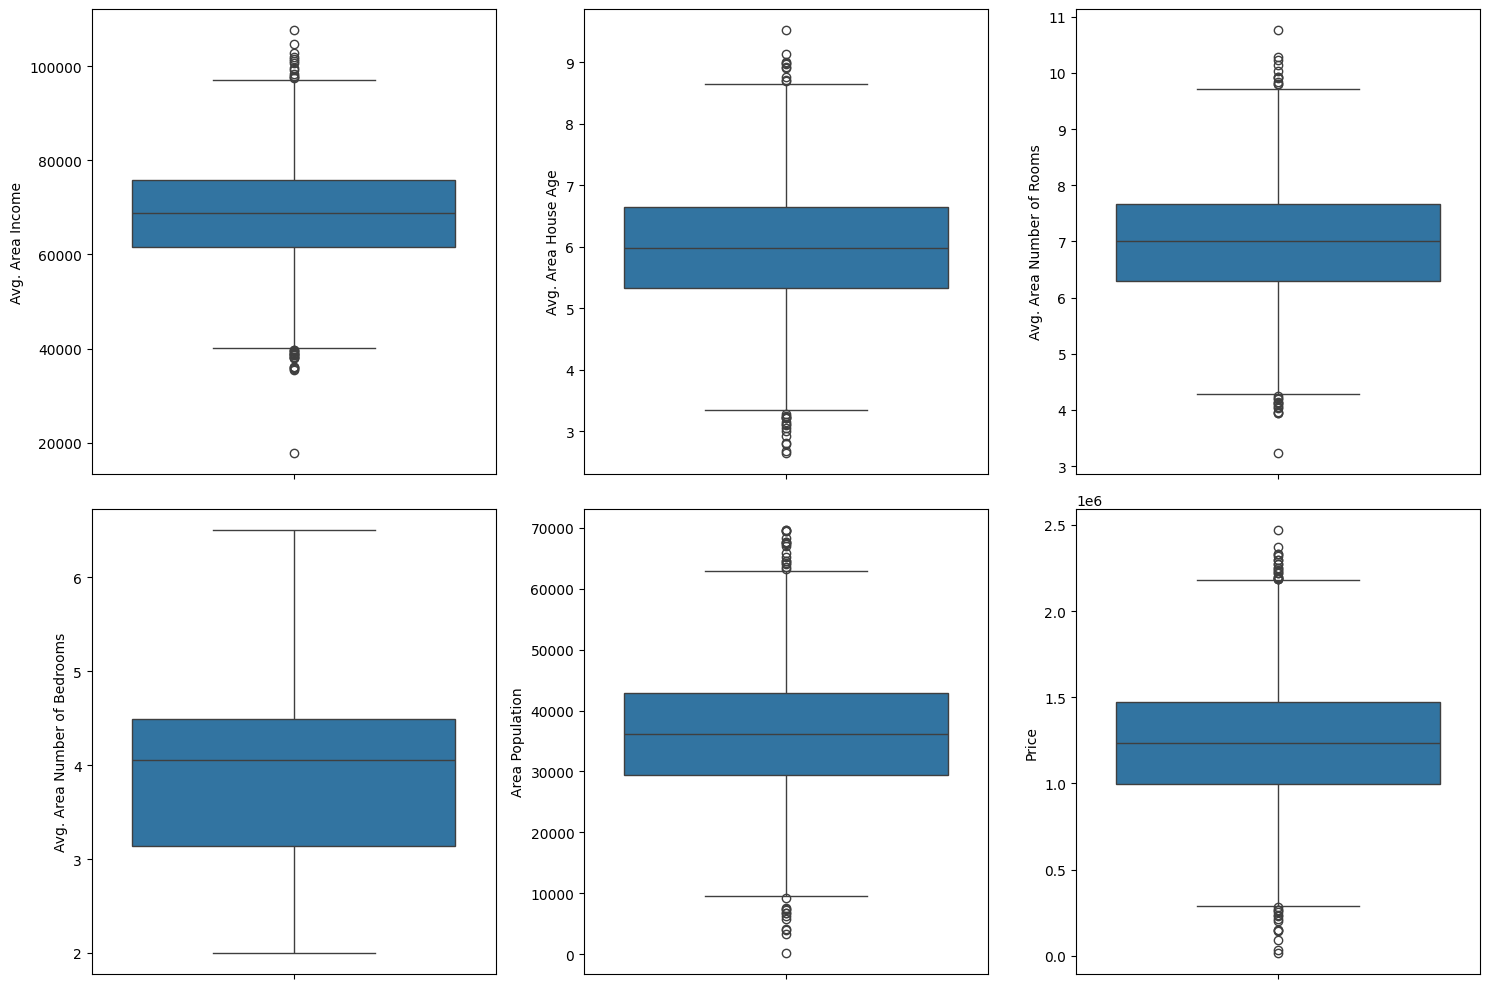

In [86]:
fig, axs = plt.subplots(2,3, figsize = (15,10))
plt1 = sns.boxplot(housing['Avg. Area Income'], ax = axs[0,0])
plt2 = sns.boxplot(housing['Avg. Area House Age'], ax = axs[0,1])
plt3 = sns.boxplot(housing['Avg. Area Number of Rooms'], ax = axs[0,2])
plt4 = sns.boxplot(housing['Avg. Area Number of Bedrooms'], ax = axs[1,0])
plt5 = sns.boxplot(housing['Area Population'], ax = axs[1,1])
plt6 = sns.boxplot(housing['Price'], ax = axs[1,2])

plt.tight_layout()

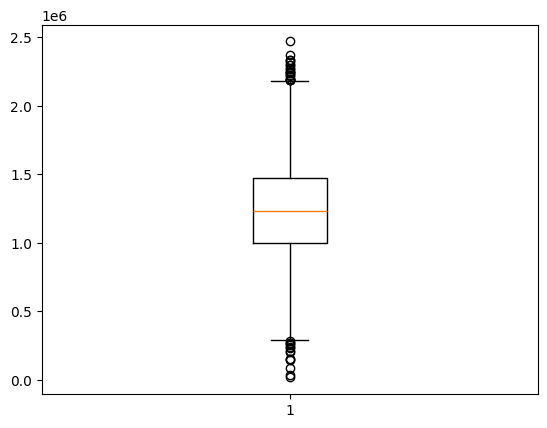

In [87]:
plt.boxplot(housing['Price'])
Q1 = housing['Price'].quantile(0.25)
Q3 = housing['Price'].quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing['Price'] >= Q1 - 1.5*IQR) & (housing['Price'] <= Q3 + 1.5*IQR)]

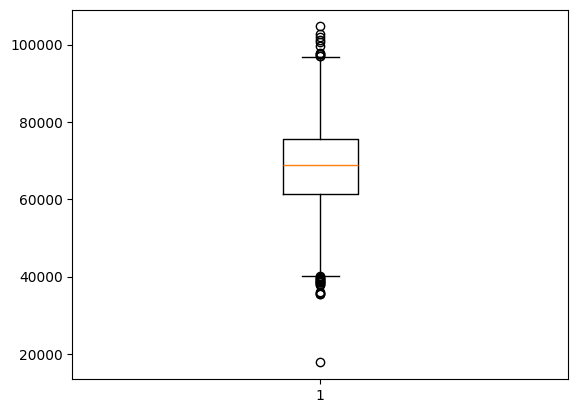

In [88]:
plt.boxplot(housing['Avg. Area Income'])
Q1 = housing['Avg. Area Income'].quantile(0.25)
Q3 = housing['Avg. Area Income'].quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing['Avg. Area Income'] >= Q1 - 1.5*IQR) & (housing['Avg. Area Income'] <= Q3 + 1.5*IQR)]

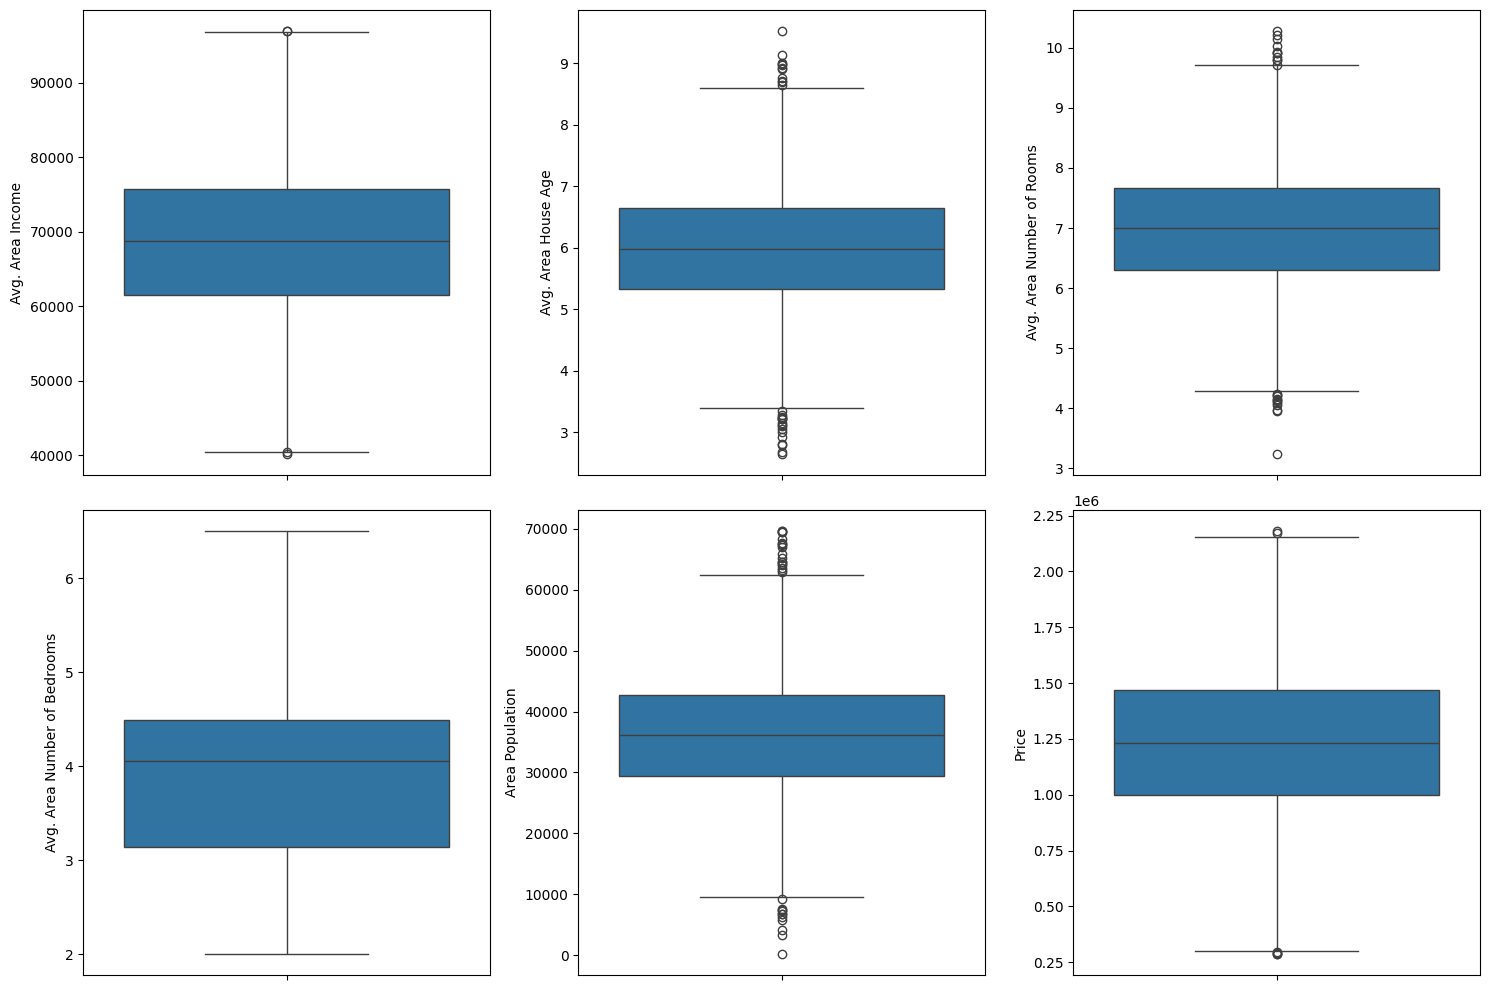

In [89]:
fig, axs = plt.subplots(2,3, figsize = (15,10))
plt1 = sns.boxplot(housing['Avg. Area Income'], ax = axs[0,0])
plt2 = sns.boxplot(housing['Avg. Area House Age'], ax = axs[0,1])
plt3 = sns.boxplot(housing['Avg. Area Number of Rooms'], ax = axs[0,2])
plt4 = sns.boxplot(housing['Avg. Area Number of Bedrooms'], ax = axs[1,0])
plt5 = sns.boxplot(housing['Area Population'], ax = axs[1,1])
plt6 = sns.boxplot(housing['Price'], ax = axs[1,2])

plt.tight_layout()

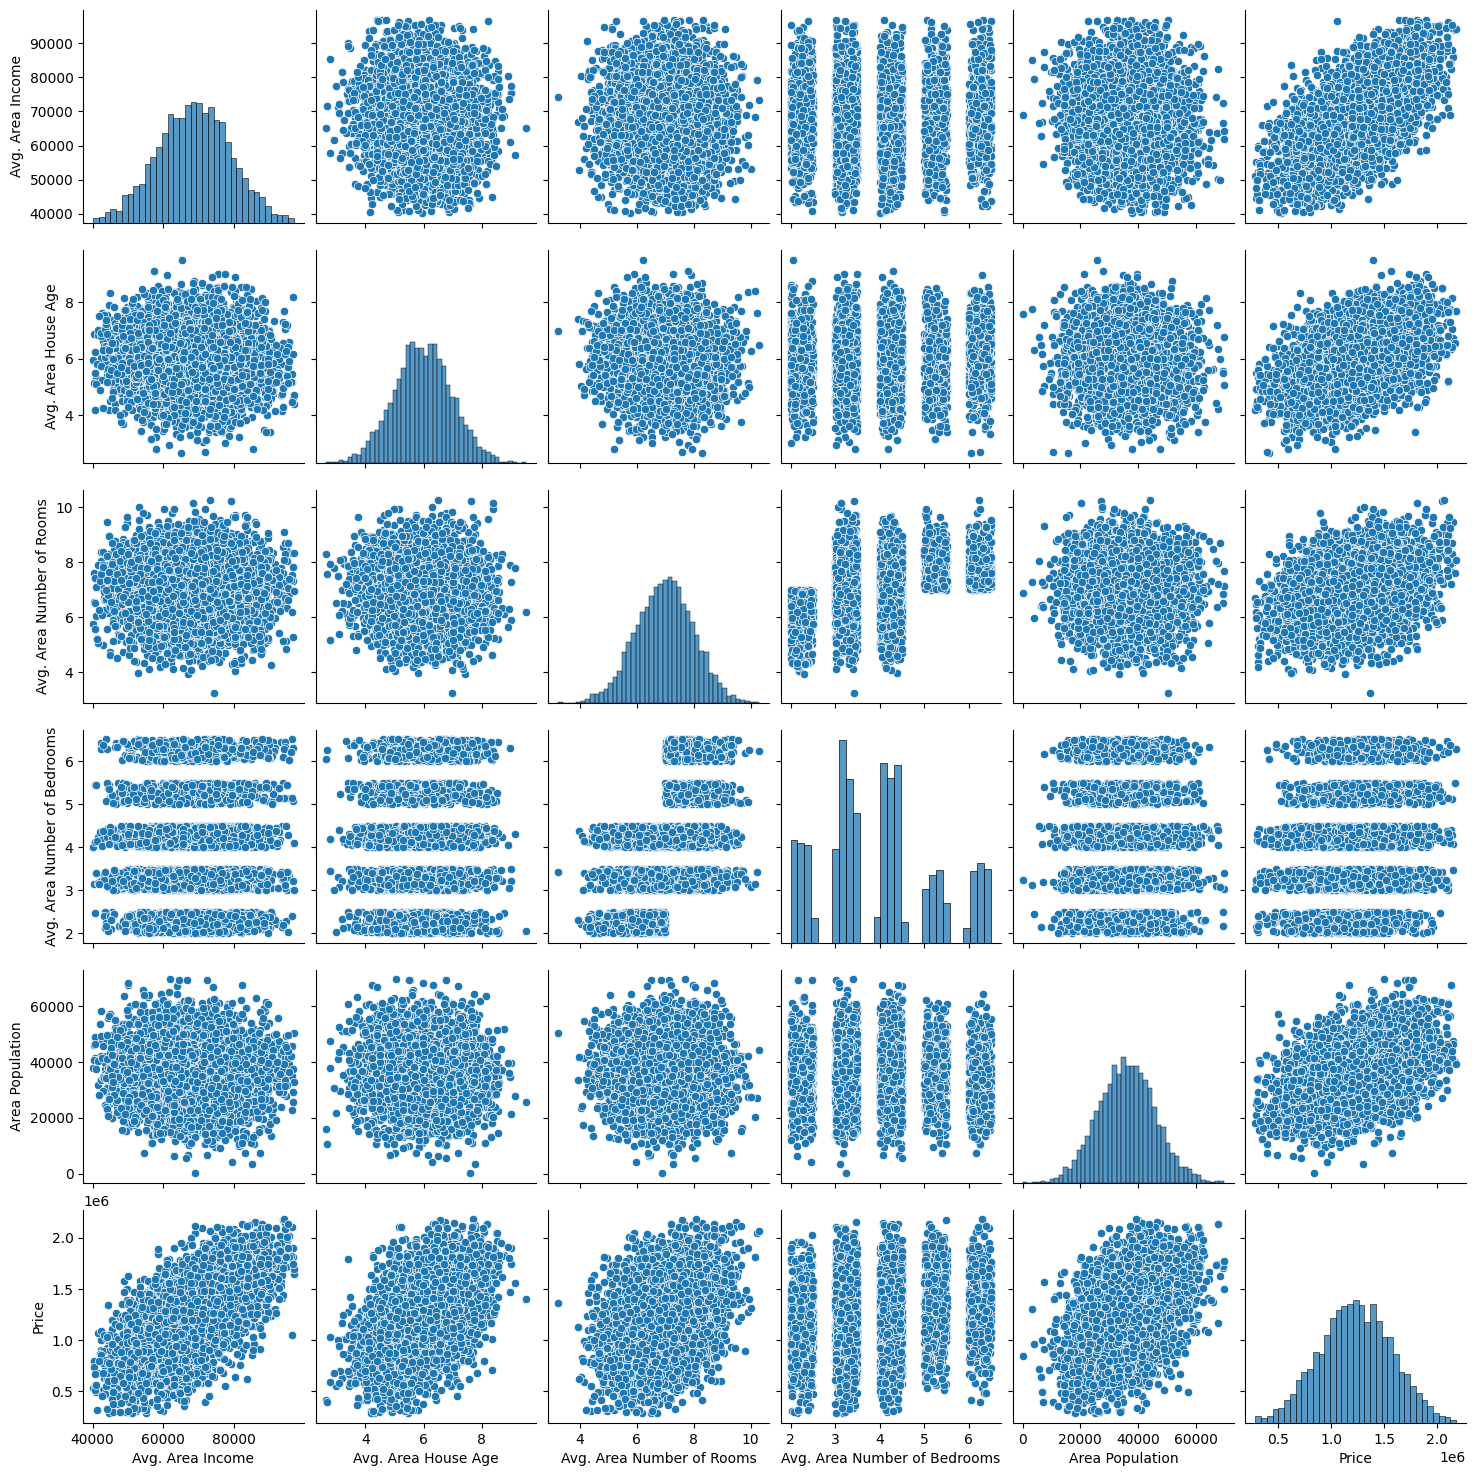

In [90]:
sns.pairplot(housing)
plt.show()

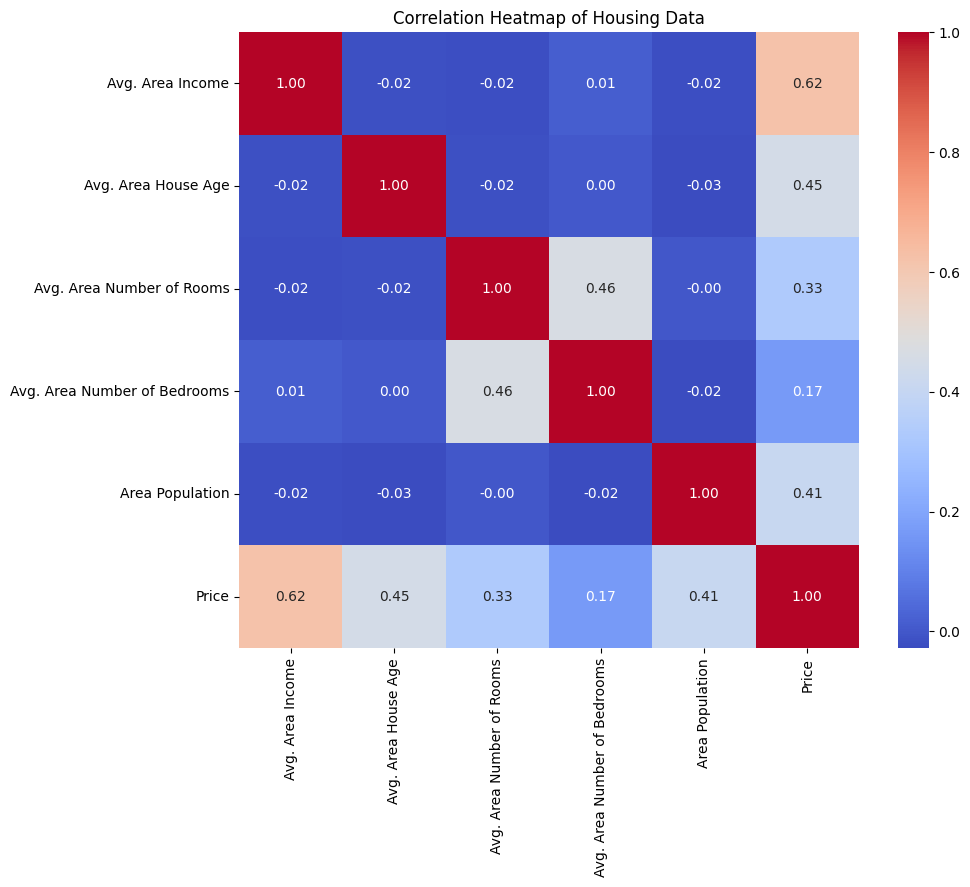

In [91]:
plt.figure(figsize=(10, 8))
numeric_housing = housing.select_dtypes(include=[np.number])
sns.heatmap(numeric_housing.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Housing Data')
plt.show()

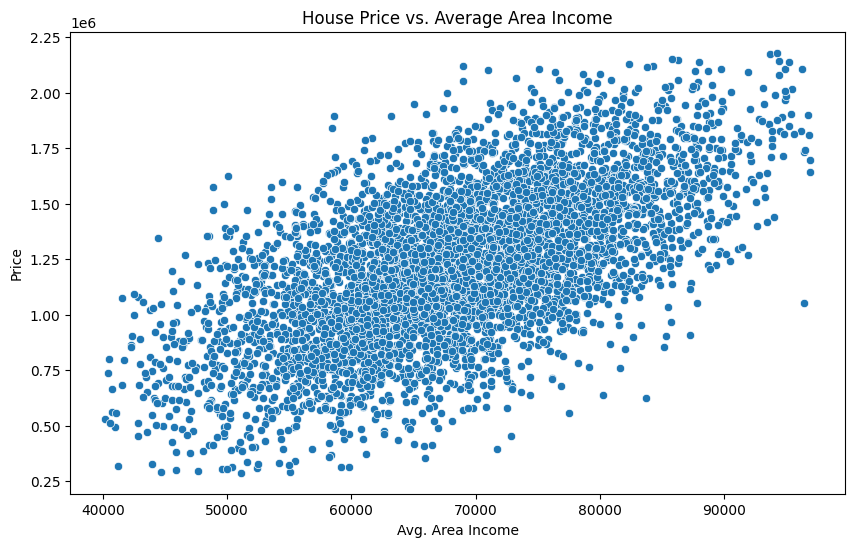

In [92]:
plt.figure(figsize = (10, 6))
sns.scatterplot(x = 'Avg. Area Income', y = 'Price', data = housing)
plt.title('House Price vs. Average Area Income')
plt.show()

In [93]:


housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4936 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              4936 non-null   float64
 1   Avg. Area House Age           4936 non-null   float64
 2   Avg. Area Number of Rooms     4936 non-null   float64
 3   Avg. Area Number of Bedrooms  4936 non-null   float64
 4   Area Population               4936 non-null   float64
 5   Price                         4936 non-null   float64
 6   Address                       4936 non-null   object 
dtypes: float64(6), object(1)
memory usage: 308.5+ KB


In [94]:


housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [95]:

pass

In [96]:

housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [97]:
# This column does not exist in the housing dataset
# status = pd.get_dummies(housing['chest pain type'], prefix='cp', drop_first=True)
# status.head()

In [98]:
# This line is being skipped because 'status' was for a different dataset
# housing = pd.concat([housing, status], axis = 1)

In [99]:


housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [100]:

pass

In [101]:
housing.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [102]:
from sklearn.model_selection import train_test_split


np.random.seed(0)
df_train, df_test = train_test_split(housing, train_size = 0.7, test_size = 0.3, random_state = 100)

In [103]:
from sklearn.preprocessing import MinMaxScaler

In [104]:
scaler = MinMaxScaler()

In [105]:
num_vars = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']
df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

In [106]:
df_train.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4337,0.488764,0.384155,0.407118,0.477778,0.364317,0.312370,"070 Sanchez Knoll Suite 569\nSaraville, MP 39758"
1951,0.815028,0.529595,0.872218,0.971111,0.399526,0.813802,"8452 John Spring Suite 590\nGutierrezberg, DE ..."
3980,0.578062,0.360698,0.514609,0.491111,0.543320,0.519320,"039 Riley Divide\nNorth Seanmouth, AK 27303-1827"
3277,0.414290,0.488804,0.581838,0.900000,0.449769,0.532899,"4374 Lang Vista\nLucasborough, MO 50846"
2115,0.390864,0.549456,0.626246,0.264444,0.660284,0.574753,"8553 Donald Avenue\nBakerville, SD 40866"


In [107]:
df_train.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000
mean,0.500528,0.474564,0.532251,0.437968,0.495963,0.498798
std,0.182590,0.145657,0.141872,0.274103,0.147648,0.179339
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.376353,0.378709,0.435207,0.253333,0.395339,0.378016
50%,0.503169,0.473400,0.533717,0.455556,0.493887,0.500132
75%,0.625484,0.575141,0.628425,0.553333,0.593742,0.623773
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


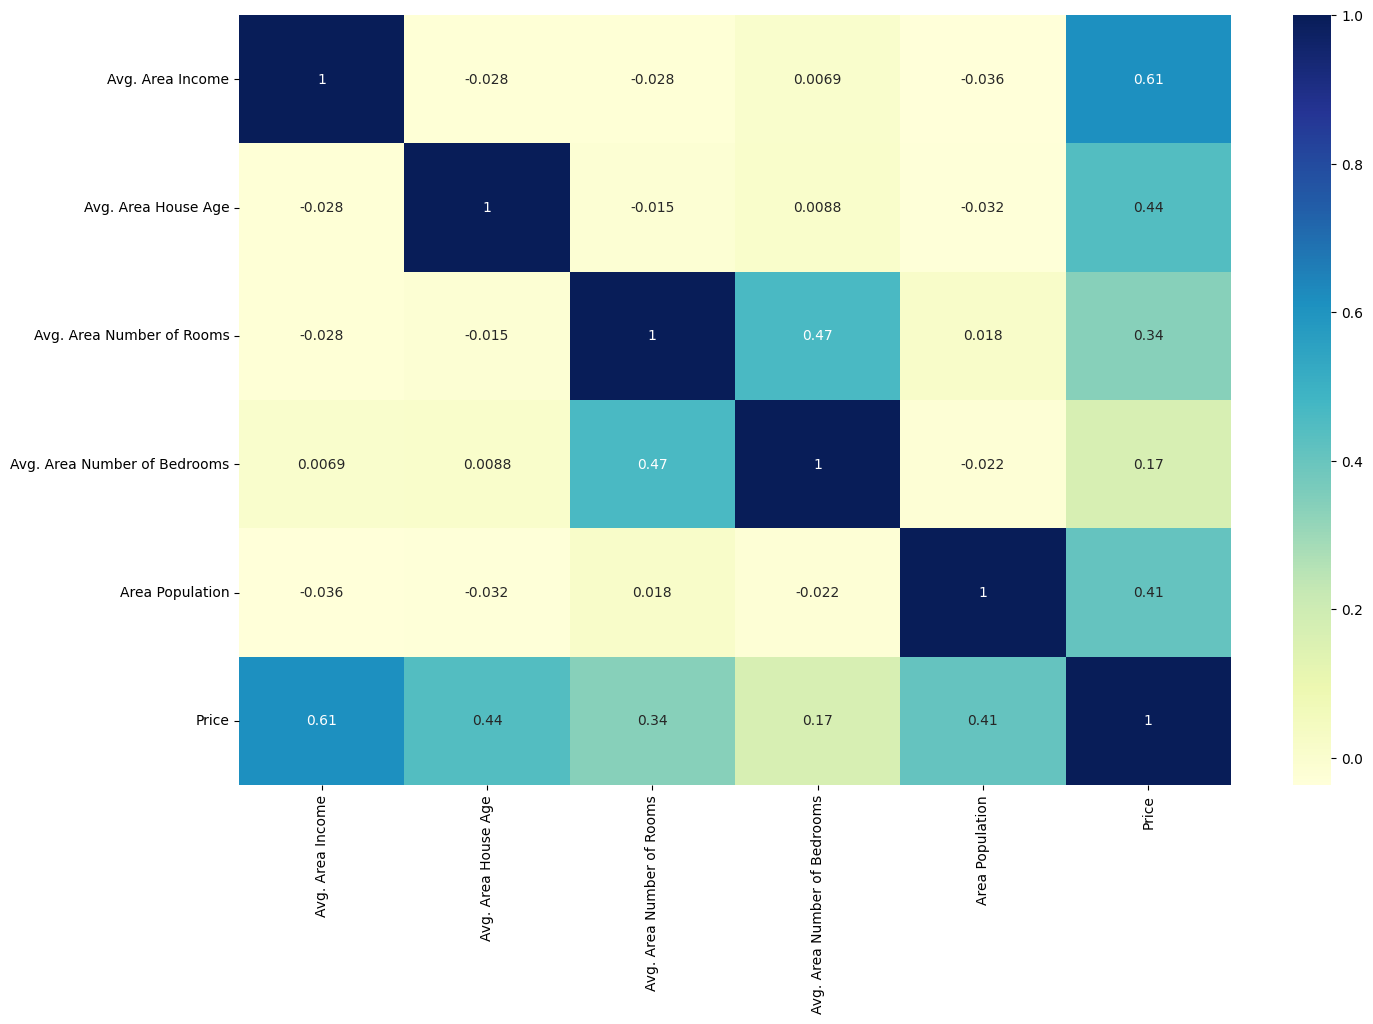

In [108]:
plt.figure(figsize = (16, 10))
numeric_df = df_train.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot = True, cmap="YlGnBu")
plt.show()

In [109]:
y_train = df_train.pop('Price')
X_train = df_train

In [110]:

from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [111]:
lm = LinearRegression()
# We drop 'Address' because it's a string column and cannot be used for regression
lm.fit(X_train.drop('Address', axis=1), y_train)

LinearRegression()

In [112]:
rfe = RFE(estimator=lm, n_features_to_select=6)             # running RFE
# Dropping 'Address' because RFE requires numeric input
rfe = rfe.fit(X_train.drop('Address', axis=1), y_train)

In [113]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('Avg. Area Income', np.True_, np.int64(1)),
 ('Avg. Area House Age', np.True_, np.int64(1)),
 ('Avg. Area Number of Rooms', np.True_, np.int64(1)),
 ('Avg. Area Number of Bedrooms', np.True_, np.int64(1)),
 ('Area Population', np.True_, np.int64(1))]

In [114]:
# We index against the columns used in RFE (dropping Address)
col = X_train.drop('Address', axis=1).columns[rfe.support_]
col

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population'],
      dtype='object')

In [115]:
# Filter the numeric columns only to match the RFE support mask
X_train.drop('Address', axis=1).columns[~rfe.support_]

Index([], dtype='object')

In [116]:

X_train_rfe = X_train[col]

In [117]:

import statsmodels.api as sm
X_train_rfe = sm.add_constant(X_train_rfe)

In [118]:
import numpy as np

lm = sm.OLS(y_train.astype(float), X_train_rfe.astype(float)).fit()   # Running the linear model

In [119]:

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     7266.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:03:10   Log-Likelihood:                 5259.6
No. Observations:                3455   AIC:                        -1.051e+04
Df Residuals:                    3449   BIC:                        -1.047e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [120]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [121]:
vif = pd.DataFrame()

X = X_train_rfe.astype(float)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,47.08
3,Avg. Area Number of Rooms,1.28
4,Avg. Area Number of Bedrooms,1.28
1,Avg. Area Income,1.00
2,Avg. Area House Age,1.00
5,Area Population,1.00


In [122]:
y_train_price = lm.predict(X_train_rfe)

In [123]:
res = (y_train_price - y_train)

In [124]:

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 0, 'Errors')

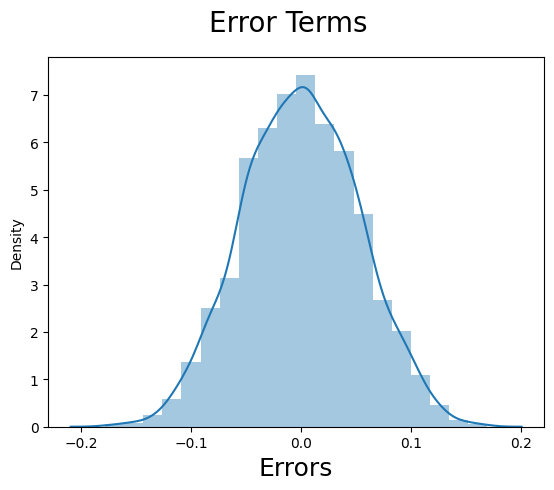

In [125]:

fig = plt.figure()
sns.distplot((y_train - y_train_price), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)
plt.xlabel('Errors', fontsize = 18)

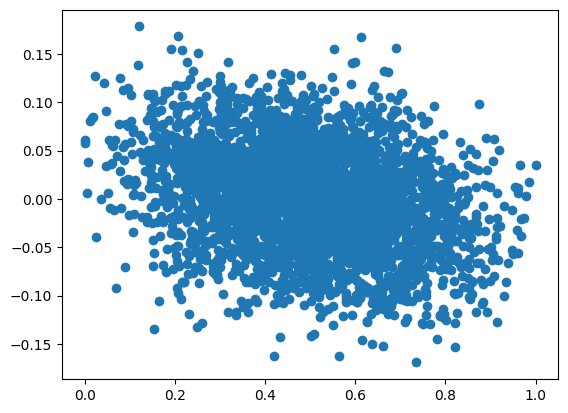

In [126]:
plt.scatter(y_train,res)
plt.show()

In [127]:
num_vars = ['area','stories', 'bathrooms', 'airconditioning', 'prefarea','parking','price']

In [128]:
num_vars = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']
df_test[num_vars] = scaler.transform(df_test[num_vars])

In [129]:
y_test = df_test.pop('Price')
X_test = df_test

In [130]:

X_test = sm.add_constant(X_test)

In [131]:
X_test = sm.add_constant(X_test)
X_test_rfe = X_test[X_train_rfe.columns]
y_pred = lm.predict(X_test_rfe)

In [132]:

y_pred = lm.predict(X_test_rfe)

In [133]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9117880930152514

Text(0, 0.5, 'y_pred')

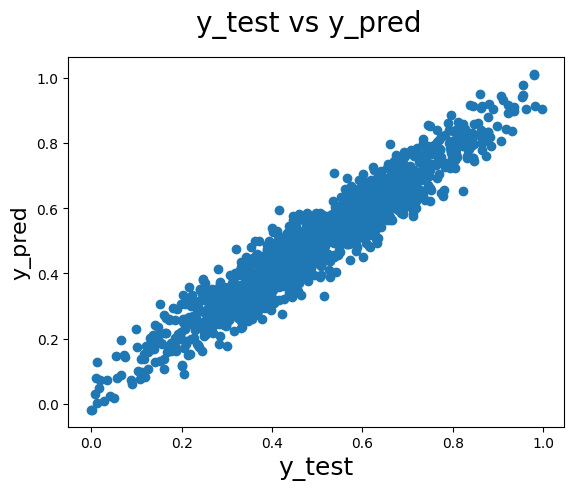

In [134]:

fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)
plt.xlabel('y_test', fontsize=18)
plt.ylabel('y_pred', fontsize=16)


We can see that the equation of our best fitted line is:

$ price = 0.35  \times  area + 0.20  \times  bathrooms + 0.19 \times stories+ 0.10 \times airconditioning + 0.10 \times parking + 0.11 \times prefarea $
